In [1]:
import pandas as pd
from category_encoders import TargetEncoder

# =============================================
# 1. Load cleaned datasets
# ==============================================
train_df = pd.read_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\cleaned_train.csv')
eval_df = pd.read_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\cleaned_eval.csv')
holdout_df = pd.read_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\cleaned_holdout.csv')

pd.set_option('display.max_columns', None) # show all columns
pd.set_option('display.max_rows', None)    # show all rows

print("Train date range:", train_df['Datetime'].min(), "to", train_df['Datetime'].max())
print("Eval date range:", eval_df['Datetime'].min(), "to", eval_df['Datetime'].max())
print("Eval date range:", holdout_df['Datetime'].min(), "to", holdout_df['Datetime'].max())

# Ensuring datetime
train_df['Datetime'] = pd.to_datetime(train_df['Datetime'])
eval_df['Datetime'] = pd.to_datetime(eval_df['Datetime'])
holdout_df['Datetime'] = pd.to_datetime(holdout_df['Datetime'])

Train date range: 2004-10-01 01:00:00 to 2011-12-31 23:00:00
Eval date range: 2012-01-01 00:00:00 to 2015-12-31 23:00:00
Eval date range: 2016-01-01 00:00:00 to 2018-08-03 00:00:00


In [2]:
# ==================================
# 2. Date Features
# ==================================
def add_date_features(df):
    df["year"] = df["Datetime"].dt.year
    df["month"] = df["Datetime"].dt.month
    df["day"] = df["Datetime"].dt.day
    df['hour'] = df["Datetime"].dt.hour

    # Reorder the columnns
    df.insert(1, "year", df.pop("year"))
    df.insert(2, "month", df.pop("month"))
    df.insert(3, "day", df.pop("day")) 
    df.insert(4, "hour", df.pop("hour"))
    return df

train_df = add_date_features(train_df)
eval_df = add_date_features(eval_df)
holdout_df = add_date_features(holdout_df)

    

In [3]:
print(train_df.shape)
train_df.head(2)

(62920, 6)


,Datetime,year,month,day,hour,AEP_MW
0,2004-10-01 01:00:00,2004,10,1,1,12379.0
1,2004-10-01 02:00:00,2004,10,1,2,11935.0


In [4]:
train_df.dtypes

Datetime    datetime64[ns]
year                 int32
month                int32
day                  int32
hour                 int32
AEP_MW             float64
dtype: object

In [5]:
print(eval_df.shape)
eval_df.head(2)

(34923, 6)


,Datetime,year,month,day,hour,AEP_MW
0,2012-01-01 00:00:00,2012,1,1,0,14181.0
1,2012-01-01 01:00:00,2012,1,1,1,13812.0


In [6]:
print(holdout_df.shape) 
holdout_df.head(2)

(22670, 6)


,Datetime,year,month,day,hour,AEP_MW
0,2016-01-01 00:00:00,2016,1,1,0,13487.0
1,2016-01-01 01:00:00,2016,1,1,1,13135.0


In [7]:
# ==========================
# Drop unused column(s)
# ===========================
drop_cols = ["Datetime"]
train_df.drop(columns=drop_cols, inplace=True)
eval_df.drop(columns=drop_cols, inplace=True)
holdout_df.drop(columns=drop_cols, inplace=True)

In [8]:
print(train_df.shape)
train_df.head(2)

(62920, 5)


,year,month,day,hour,AEP_MW
0,2004,10,1,1,12379.0
1,2004,10,1,2,11935.0


In [9]:
# ===================================
# Save feature-engineered datasets
# ====================================
train_df.to_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\feature_engineered_train.csv', index=False)
eval_df.to_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\featured_engineered_eval.csv', index=False)
holdout_df.to_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\featured_engineered_holdout.csv', index=False)

print("Feature engineering complete.")
print("Train shape:", train_df.shape)
print("Eval shape:", eval_df.shape)
print("Holdout shape:", holdout_df.shape)

Feature engineering complete.
Train shape: (62920, 5)
Eval shape: (34923, 5)
Holdout shape: (22670, 5)


Multicolinearity using either:
* VIF or
* Correlation matrix


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, target_col=None):
    """
    Calculate Variance Inflaction Factor (VIF) for each numeric column in df
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include="number").copy()  # include=['float64', 'int64']

    # Drop target if provided
    if target_col and target_col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[target_col])

    # Add constants for statsmodels
    X = add_constant(numeric_df)

    # Compute VIF (skip the first column = constant)
    vif_data = pd.DataFrame()
    vif_data["features"] = numeric_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i + 1) # skip constat at index 0
        for i in range(len(numeric_df.columns))
    ]

    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)


# Look at VIF and correlation with the original training dataset
df = pd.read_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\feature_engineered_train.csv')
vif_table = calculate_vif(df, target_col="AEP_MW")
print(vif_table)

  features       VIF
0    month  1.006961
1     year  1.006832
2      day  1.000133
3     hour  1.000001


Text(0.5, 1.0, 'Correlation Matrix of Numeric Features')

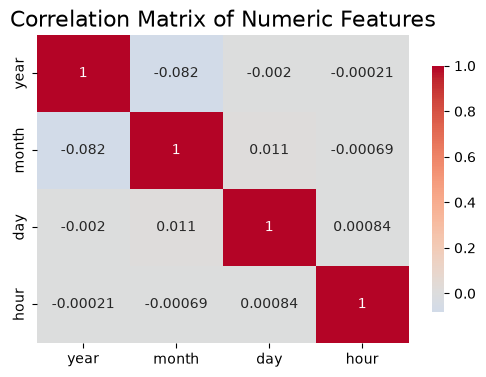

In [11]:
# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

# select only numeric features (exclude the target feature)
numeric_df = df.select_dtypes(include='number').drop(columns=["AEP_MW"], errors="ignore")

# Compute correlation matrix
Corr_matrix = numeric_df.corr()

# Display full matrix as heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    Corr_matrix, 
    cmap="coolwarm",
    center=0,
    annot=True, # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)

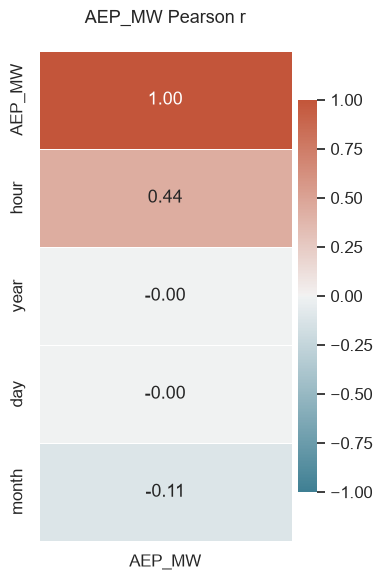

In [12]:
# Compute correlation with target feature - AEP_MW
num_cols = df.select_dtypes("number").columns
corr_vec = df[num_cols].corr(method="pearson")["AEP_MW"].sort_values(ascending=False)
sns.set_theme(style="white")
sns.set(font_scale=1.1)
plt.figure(figsize=(4,6))
ax = sns.heatmap(
    corr_vec.to_frame(),
    annot=True, fmt=".2f",
    vmin=-1, vmax=1,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0,
    linewidths=.5, linecolor='white',
    cbar_kws={"shrink":0.8, "pad":0.02}
)
ax.set_title("AEP_MW Pearson r", pad=20)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()